# Retail Customer Profitability & Churn Risk Analysis (RFM-Based)

This project analyzes revenue concentration, profit dependency, and churn risk using customer segmentation techniques to identify financial exposure and retention opportunities.

## 1. Data Preparation

We begin by loading and preparing the dataset for analysis.

In [116]:
import pandas as pd
import matplotlib.pyplot as plt


In [117]:
df = pd.read_csv('data/Superstore.csv', encoding='latin1')

In [118]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [119]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [120]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [123]:
df['Profit_Margin'] = df['Profit'] / df['Sales']

In [124]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit',
       'Profit_Margin'],
      dtype='object')

In [125]:
df = pd.read_csv('Superstore.csv', encoding='latin1')

# Clean column names
df.columns = df.columns.str.strip().str.replace(" ", "_")

# Now this will work
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

In [126]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

In [ ]:
df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month

## 2. Key Performance Indicators (KPI)

In [ ]:
# Total Revenue
total_revenue = df['Sales'].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 2297200.8603000003


In [ ]:
# Revenue by Region
region_sales = df.groupby('Region')['Sales'].sum()
print(region_sales)

Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64


In [ ]:
# Top Customers
top_customers = df.groupby('Customer_Name')['Sales'].sum().sort_values(ascending=False).head(10)
print(top_customers)

Customer_Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64


In [ ]:
# Monthly Revenue
monthly_sales = df.groupby(['Year','Month'])['Sales'].sum()
print(monthly_sales)

Year  Month
2014  1         14236.8950
      2          4519.8920
      3         55691.0090
      4         28295.3450
      5         23648.2870
      6         34595.1276
      7         33946.3930
      8         27909.4685
      9         81777.3508
      10        31453.3930
      11        78628.7167
      12        69545.6205
2015  1         18174.0756
      2         11951.4110
      3         38726.2520
      4         34195.2085
      5         30131.6865
      6         24797.2920
      7         28765.3250
      8         36898.3322
      9         64595.9180
      10        31404.9235
      11        75972.5635
      12        74919.5212
2016  1         18542.4910
      2         22978.8150
      3         51715.8750
      4         38750.0390
      5         56987.7280
      6         40344.5340
      7         39261.9630
      8         31115.3743
      9         73410.0249
      10        59687.7450
      11        79411.9658
      12        96999.0430
2017  1         

In [ ]:
total_revenue = df['Sales'].sum()
print('Total Revenue:', round(total_revenue, 2))

Total Revenue: 2297200.86


In [ ]:
total_profit = df['Profit'].sum()
print('Total Profit:', round(total_profit, 2))

Total Profit: 286397.02


In [ ]:
profit_margin = total_profit/total_revenue
print('Overall Profit Margin:', round(profit_margin, 4))

Overall Profit Margin: 0.1247


In [ ]:
region_analysis = df.groupby('Region').agg({
    'Sales': 'sum',
    'Profit': 'sum'
})

region_analysis['Profit_margin'] = region_analysis['Profit'] / region_analysis['Sales']

print(region_analysis)

               Sales       Profit  Profit_margin
Region                                          
Central  501239.8908   39706.3625       0.079216
East     678781.2400   91522.7800       0.134834
South    391721.9050   46749.4303       0.119343
West     725457.8245  108418.4489       0.149448


In [ ]:
category_analysis = df.groupby('Category').agg({
    'Sales': 'sum',
    'Profit': 'sum'
})

category_analysis['Profit_Margin'] = category_analysis['Profit'] / category_analysis['Sales']

print(category_analysis)

                       Sales       Profit  Profit_Margin
Category                                                
Furniture        741999.7953   18451.2728       0.024867
Office Supplies  719047.0320  122490.8008       0.170352
Technology       836154.0330  145454.9481       0.173957


In [ ]:
top_customers = df.groupby('Customer_Name')['Sales'].sum().sort_values(ascending=False).head(10)

print(top_customers)

Customer_Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64


In [ ]:
# Check Revenue Concentration

In [ ]:
total_revenue = df['Sales'].sum()

top_10_revenue = df.groupby('Customer_Name')['Sales'].sum() \
                    .sort_values(ascending=False).head(10).sum()

percentage = (top_10_revenue / total_revenue) * 100

print("Top 10 Customers contribute:", round(percentage,2), "% of total revenue")

Top 10 Customers contribute: 6.7 % of total revenue


In [ ]:
monthly_sales = df.groupby(df['Order_Date'].dt.to_period('M'))['Sales'].sum()

print(monthly_sales)

Order_Date
2014-01     14236.8950
2014-02      4519.8920
2014-03     55691.0090
2014-04     28295.3450
2014-05     23648.2870
2014-06     34595.1276
2014-07     33946.3930
2014-08     27909.4685
2014-09     81777.3508
2014-10     31453.3930
2014-11     78628.7167
2014-12     69545.6205
2015-01     18174.0756
2015-02     11951.4110
2015-03     38726.2520
2015-04     34195.2085
2015-05     30131.6865
2015-06     24797.2920
2015-07     28765.3250
2015-08     36898.3322
2015-09     64595.9180
2015-10     31404.9235
2015-11     75972.5635
2015-12     74919.5212
2016-01     18542.4910
2016-02     22978.8150
2016-03     51715.8750
2016-04     38750.0390
2016-05     56987.7280
2016-06     40344.5340
2016-07     39261.9630
2016-08     31115.3743
2016-09     73410.0249
2016-10     59687.7450
2016-11     79411.9658
2016-12     96999.0430
2017-01     43971.3740
2017-02     20301.1334
2017-03     58872.3528
2017-04     36521.5361
2017-05     44261.1102
2017-06     52981.7257
2017-07     45264.4160


<Axes: xlabel='Order_Date'>

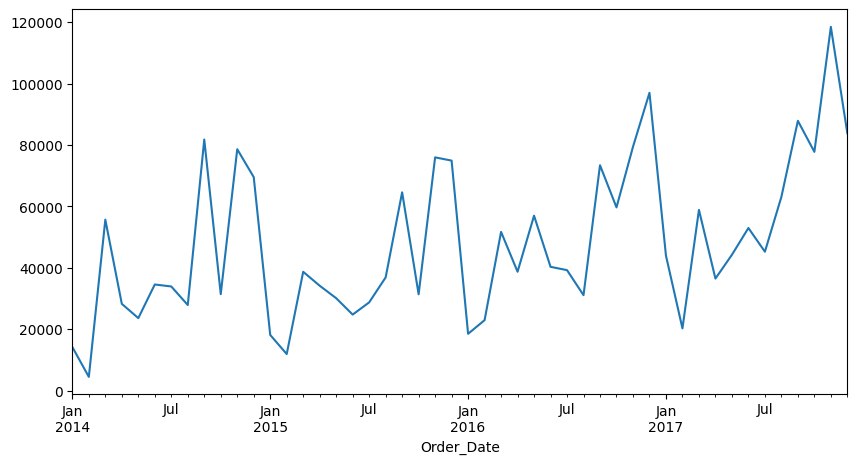

In [ ]:
monthly_sales.plot(figsize=(10,5))

In [ ]:
# Check Profit

In [ ]:
top_10_profit = df.groupby('Customer_Name')['Profit'].sum() \
.sort_values(ascending=False).head(10)
print(top_10_profit)

Customer_Name
Tamara Chand            8981.3239
Raymond Buch            6976.0959
Sanjit Chand            5757.4119
Hunter Lopez            5622.4292
Adrian Barton           5444.8055
Tom Ashbrook            4703.7883
Christopher Martinez    3899.8904
Keith Dawkins           3038.6254
Andy Reiter             2884.6208
Daniel Raglin           2869.0760
Name: Profit, dtype: float64


If top customers:

Generate significant revenue
Have strong margins
Then: Create Loyalty program

Example ideas:
Early access to products
Volume-based discounts
Personalized offers

If revenue is well distributed:
Better strategy:

Segment customers
Focus on mid-tier customers
Increase repeat purchase rate

In [ ]:
customer_sales = df.groupby('Customer_Name')['Sales'].sum().sort_values(ascending=False)

customer_sales.describe()

count      793.000000
mean      2896.848500
std       2628.670117
min          4.833000
25%       1146.050000
50%       2256.394000
75%       3785.276000
max      25043.050000
Name: Sales, dtype: float64

In [ ]:
customer_frequency =df.groupby('Customer_Name')['Order_ID'].nunique().sort_values(ascending=False)

customer_frequency.head(10)

Customer_Name
Emily Phan             17
Sally Hughsby          13
Erin Ashbrook          13
Patrick Gardner        13
Zuschuss Carroll       13
Chloris Kastensmidt    13
Joel Eaton             13
Noel Staavos           13
Rick Bensley           12
Resi Pölking           12
Name: Order_ID, dtype: int64

In [ ]:
# PARETO CALCULATION
customer_sales = df.groupby('Customer_Name')['Sales'].sum().sort_values(ascending=False)

total_customer = len(customer_sales)

top_20_percent_count = int(total_customer * 0.20)

In [ ]:
top_20_percent_revenue = customer_sales.head(top_20_percent_count).sum()

total_revenue = df['Sales'].sum()

percentage = (top_20_percent_revenue / total_revenue) * 100

print('Top 20% Cutomers contribute:', round(percentage, 2), '% of total revenue')

Top 20% Cutomers contribute: 47.96 % of total revenue


In [ ]:
customer_profit = df.groupby('Customer_Name')['Profit'].sum().sort_values(ascending=False)

In [ ]:
total_customer = len(customer_profit)

In [ ]:
top_20_percent_count = int(total_customer * 0.20)

In [ ]:
top_20_percent_profit = customer_profit.head(top_20_percent_count).sum()

total_profit = df['Profit'].sum()

percentage_profit = (top_20_percent_profit / total_profit) * 100

print('Top 20% Cutomers contribute:', round(percentage_profit, 2), '% of total profit')

Top 20% Cutomers contribute: 81.43 % of total profit


In [ ]:
top_customers = customer_profit.head(top_20_percent_count).index

df[df['Customer_Name'].isin(top_customers)]['Discount'].mean()

np.float64(0.11772603802871556)

In [ ]:
customer_profit.sort_values().head(10)

Customer_Name
Cindy Stewart      -6626.3895
Grant Thornton     -4108.6589
Luke Foster        -3583.9770
Sharelle Roach     -3333.9144
Henry Goldwyn      -2797.9635
Nathan Cano        -2204.8072
Sean Braxton       -2082.7451
Sean Miller        -1980.7393
Christine Phan     -1850.3029
Natalie Fritzler   -1695.9714
Name: Profit, dtype: float64

In [ ]:
df[df['Customer_Name'].isin(top_customers)].groupby('Category')['Profit'].sum()

Category
Furniture           24327.9363
Office Supplies     88531.7919
Technology         120341.5526
Name: Profit, dtype: float64

In [ ]:
df.groupby('Category')['Profit'].sum()

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64

In [ ]:
category_margin = df.groupby('Category').agg({
    'Sales': 'sum',
    'Profit': 'sum'
})

category_margin['Profit_Margin'] = category_margin['Profit'] / category_margin['Sales']

print(category_margin)

                       Sales       Profit  Profit_Margin
Category                                                
Furniture        741999.7953   18451.2728       0.024867
Office Supplies  719047.0320  122490.8008       0.170352
Technology       836154.0330  145454.9481       0.173957


In [ ]:
df.groupby('Category')['Discount'].mean()

Category
Furniture          0.173923
Office Supplies    0.157285
Technology         0.132323
Name: Discount, dtype: float64

In [ ]:
customer_profit=df.groupby('Customer_Name')['Profit'].sum().sort_values(ascending=False)

total_customers = len(customer_profit)
top_20_percent_count = int(total_customers * 0.20)

top_customers = customer_profit.head(top_20_percent_count)

In [ ]:
top_profit = top_customers.sum()
total_profit = df['Profit'].sum()

print("Top 20% Profit Share:", round((top_profit / total_profit)*100,2), "%")

Top 20% Profit Share: 81.43 %


In [ ]:
top_10_percent_of_top = int(len(top_customers) * 0.10)

lost_profit = top_customers.head(top_10_percent_of_top).sum()

profit_loss_percentage = (lost_profit / total_profit) * 100

print("If we lose 10% of top customers, profit drops by:",
      round(profit_loss_percentage,2), "%")

If we lose 10% of top customers, profit drops by: 22.15 %


In [ ]:
customer_orders = df.groupby('Customer_Name')['Order_ID'].nunique().sort_values(ascending=False)

customer_orders.head()

Customer_Name
Emily Phan          17
Sally Hughsby       13
Erin Ashbrook       13
Patrick Gardner     13
Zuschuss Carroll    13
Name: Order_ID, dtype: int64

In [ ]:
last_purchase = df.groupby('Customer_Name')['Order_Date'].max()

recent_date = df['Order_Date'].max()

recency_days = (recent_date - last_purchase).dt.days

recency_days.sort_values(ascending=False).head()

Customer_Name
Nicole Brennan       1165
Georgia Rosenberg    1135
Ricardo Emerson      1097
Craig Molinari       1035
Valerie Takahito     1000
Name: Order_Date, dtype: int64

In [ ]:
import pandas as pd 

# Get latest date in dataset 
latest_date = df['Order_Date'].max()

# Create RFM table
rfm = df.groupby('Customer_Name').agg({
    'Order_Date': lambda x: (latest_date - x.max()).days,
    'Order_ID': 'nunique',
    'Sales': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
Customer_Name,,,
Aaron Bergman,415,3,886.156
Aaron Hawkins,12,7,1744.700
Aaron Smayling,88,7,3050.692
Adam Bellavance,54,8,7755.620
Adam Hart,34,10,3250.337


In [ ]:
rfm[(rfm['Recency']>90) & (rfm['Monetary']> rfm.Monetary.mean())]

,Recency,Frequency,Monetary
Customer_Name,,,
Alex Avila,184,5,5563.5600
Anna Gayman,97,7,3489.0396
Anna Häberlin,410,12,7888.2940
Anne McFarland,162,8,5664.0220
Anthony Johnson,166,7,4501.3910
...,...,...,...
Tom Boeckenhauer,202,7,9133.9900
Tom Prescott,104,5,5329.0048
Tracy Blumstein,107,9,4737.4860


In [ ]:
avg_monetary

np.float64(2896.848499747793)

In [ ]:
avg_monetary = rfm['Monetary'].mean()

high_risk = rfm[(rfm['Recency'] > 90) & (rfm['Monetary'] > avg_monetary)]

high_risk.sort_values(by='Monetary', ascending=False)

,Recency,Frequency,Monetary
Customer_Name,,,
Tamara Chand,399,5,19052.218
Raymond Buch,96,6,15117.339
Sanjit Chand,349,9,14142.334
Becky Martin,307,4,11789.630
Seth Vernon,101,10,11470.950
...,...,...,...
Christine Kargatis,120,5,2945.321
Becky Castell,202,9,2933.676
Julie Kriz,117,10,2932.484


In [ ]:
high_risk = rfm[(rfm['Recency'] > 90) & (rfm['Monetary'] > rfm['Monetary'].mean())]

high_risk

,Recency,Frequency,Monetary
Customer_Name,,,
Alex Avila,184,5,5563.5600
Anna Gayman,97,7,3489.0396
Anna Häberlin,410,12,7888.2940
Anne McFarland,162,8,5664.0220
Anthony Johnson,166,7,4501.3910
...,...,...,...
Tom Boeckenhauer,202,7,9133.9900
Tom Prescott,104,5,5329.0048
Tracy Blumstein,107,9,4737.4860


In [ ]:
high_risk_names = high_risk.index

profit_at_risk = df[df['Customer_Name'].isin(high_risk_names)]['Profit'].sum()

total_profit = df['Profit'].sum()

print('Profit at risk %:', round((profit_at_risk / total_profit) * 100, 2), '%')

Profit at risk %: 33.68 %


If profit at risk < 2% → Not alarming

If 5–10% → Moderate concern

If 15%+ → Serious retention priority

We need to Priortise the high value customers by introducing:
Personalized offers
Sending Emails
Offer Loyalty rewards


In [ ]:
len(rfm)

793

total customers = 793

103/793 = 12.9 %

this means:

A significant high-value segment hasn't purchased recently.

This might be seasonal behavior.

Or early churn signal.

Or campaign opportunity.

So, instead of individual outreach, we would:

Create targeted reactivation campaign.

Send personalized discount emails.

Offer bundle deals.

Send 'We Miss You' campaigns.

Offer limited-time incentives.


In [ ]:
rfm['Recency'].describe()

count     793.000000
mean      146.802018
std       186.211051
min         0.000000
25%        30.000000
50%        75.000000
75%       183.000000
max      1165.000000
Name: Recency, dtype: float64

In [ ]:
high_risk_strict = rfm[(rfm['Recency'] > 183) & (rfm['Monetary'] > rfm['Monetary'].mean())]
len(high_risk_strict)

42

In [ ]:
strict_names = high_risk_strict.index

strict_profit_risk = df[df['Customer_Name'].isin(strict_names)]['Profit'].sum()

total_profit = df['Profit'].sum()

print('Strict churn profit risk %:', round((strict_profit_risk / total_profit) * 100, 2), '%')

Strict churn profit risk %: 17.64 %


Compared to earlier:

90-day threshold -> 33% profit at risk was too aggressive

183-day thrshold -> 17.64% profit at risk is more accurate 

Now, We can say:

Around 18% of profit is exposed to high churn risk.



Recency(Highest Weight)

If someone hasn't purchased in 200 days,

that's a direct churn signal.

Recency captures behavioral change fastest.

Frequency(Second Most Important)

Frequency tells us:

If they bought 20 times historically,

and now stopped - that's concerning.

If they bought once and stopped - not surprising.

Monetary(Important, But Contextual)

Monetary tells us:

How valuable they are.

But it doesn't predict churn directly.

It tells us how painful the churn would be.


In [ ]:
rfm['Recency_Score'] = rfm['Recency'] / rfm['Recency'].max()
rfm['Frequency_Score'] = 1 - (rfm['Frequency'] / rfm['Frequency'].max())
rfm['Monetary_Score'] = 1 - (rfm['Monetary'] / rfm['Monetary'].max())

rfm['Churn_Risk_Score'] = (
    0.5 * rfm['Recency_Score'] +
    0.3 * rfm['Frequency_Score'] +
    0.2 * rfm['Monetary_Score']
)

Executive Summary:

Approximately 18% of total profit is at risk due to high-value customers who have not purchased in over 183 days. Targeted retention strategies could protect nearly one-fifth of company profitability.

Question: How would I decide whether spending on retention is worth it? What metric would you calculate?

Answer:
Is the expected profit saved greater then the cost of retention.

Formula:

Expected Profit Saved - Campaign Cost

If result > 0 -> worth doing.

For EXAMPLE:

Total profit at risk = 17.64%

Let's assume total profit = $100,000.

That means $17,640 is exposed.

Now Imagine:

Retention campaign costs = $4000

Expected saved profit = 

50% x 17,640 = $8,820

Net Gain = 8,820 - 4000 = $4,820

That's positive ROI

So campaign makes sense.